# SDR-DSP Notebook

This notebook will show digital signal processing concepts commonly seen in software defined radio.

To begin, we will examine simulated signals ( sin waves, noise, along with fast fourier transforms). 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

%matplotlib inline
plt.rcParams["figure.figsize"] = (8,4)

print("=====DSP ENVIRONMENT READY!=====")

=====DSP ENVIRONMENT READY!=====


## Understanding the Math Behind the FFT

Before we rely on the numpy library to compute the fft for us, it helps to understand whats happening underneath the hood. 

### The Big Idea

The Fast Fourier Transform is a fast algorithm for computing the **Discrete Fourier Transform (DFT)** of a signal, which breaks a discrete-time signal into its frequency components.

The **DFT** of a signal is \( x[n] \) with \( N \) samples defined as: 
$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2 \pi \frac{k n}{N} } 
$$

Where :

- \( n \) is the time index / sample number
- \( k \) is the frequency index
- \($ e^{-j 2 \pi kn/N}  $\) is the complex sinusoidal basis  ( $e^{j \theta} = cos \theta + j sin \theta$ , $e^{-j \theta} = cos \theta - j sin \theta$ )
- \( X[k] \) shows how much of the frequency $(k/N \times f_s)$ is present in \( x[n]\)

We are **correlating the signal** with as many sinusoids of different frequencies - seeing how much one "fits" inside the signal

### Why the FFT Exists

The **FFT** doesn't affect the math of **DFT**, but rather changes the perspective at which the data is computed. 
It's an optimized way of solving the same equation in $( O(N \log N) )$ time instead of  $(O(N^2))$

Let's use the analogy of **counting money**. We need to pay for a product that's $100, and we have the option of counting in terms of 1 cent increments or 1 dollar increments. We count the same money, but instead **count faster by changing the denomination of money.**

### Code:
To demonstrate the mechanism, a manual script will be compared to numpy's fft function

Max absolute error:  4.80e-11, Which is ~ 0. Both functions give the same output, but significantly less time to compute
Manual DFT Time: 41.1337 ms
NumPy FFT Time: 0.098529 ms
FFT is  417.5 times faster than DFT


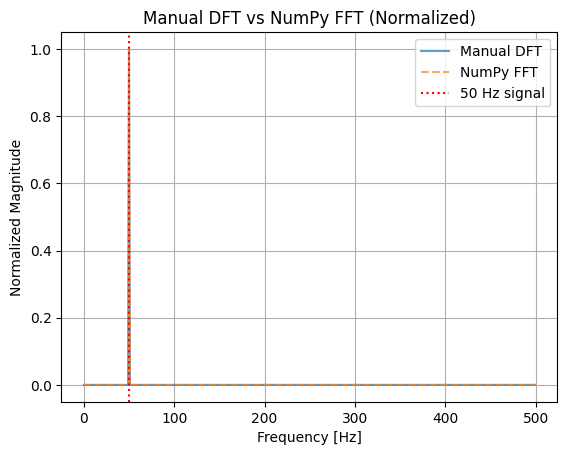

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

#Timing function for comparison
def time_function(func, *args) :
    start = time.perf_counter()
    result = func(*args)
    elapsed = time.perf_counter() - start
    return result, elapsed

#Parameters
fs = 1000 #samp freq
f = 50 # function frequency
N = 1000 #samples / fundamental period
t = np.arange(N) / fs
x = np.sin(2*np.pi * f * t)

#Manual DFT
def manual_dft(x):
    N = len(x) ## Returns length of x[n] as number of samples
    n = np.arange(N) ## arranges samples as index of time
    k = n.reshape((N, 1)) ## indexs x[n] in terms of frequency
    W = np.exp(-2j * np.pi * k * n / N) ## complex Sinusoid basis function
    X = np.dot(W,x) ## product of x[n] and complex sinusoid function aka DFT
    return X

X_manual = manual_dft(x)
freqs = np.fft.fftfreq(N,1/fs)

#compare to NumPy FFt
X_np = np.fft.fft(x)

#Verify difference
error = np.max(np.abs(X_manual - X_np))

#Time both functions
_, t_manual = time_function(manual_dft, x)
_, t_numpy  = time_function(np.fft.fft, x) 


print(f"Max absolute error: {error: .2e}, Which is ~ 0. Both functions give the same output, but significantly less time to compute")

print(f"Manual DFT Time: {t_manual * 1e3:.4f} ms")
print(f"NumPy FFT Time: {t_numpy * 1e3:.6f} ms")
print(f"FFT is  { t_manual / t_numpy:.1f} times faster than DFT")

#plot 
half = N // 2
mag_manual = np.abs(X_manual[:half]) * 2 / N
mag_np = np.abs(X_np[:half]) * 2 / N

plt.plot(freqs[:half], mag_manual, label="Manual DFT", alpha=0.7)
plt.plot(freqs[:half], mag_np, '--', label="NumPy FFT", alpha=0.7)
plt.axvline(f, color='r', linestyle=':', label=f"{f} Hz signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Normalized Magnitude")
plt.title("Manual DFT vs NumPy FFT (Normalized)")
plt.legend()
plt.grid(True)
plt.show()



### FFT Output Interpretation

Both the manual and NumPy FFT methods reveal a clear single-tone peak at **50 Hz**.  
The normalized magnitude (1.0) corresponds to the full amplitude of the input sine wave.
All other bins remain near zero, confirming the FFT isolates pure frequencies effectively.


## Synthetic 100kHz Tone 

### Objective 
Create base sinusoidal tone, complete Fast fourier transform 

### Code:

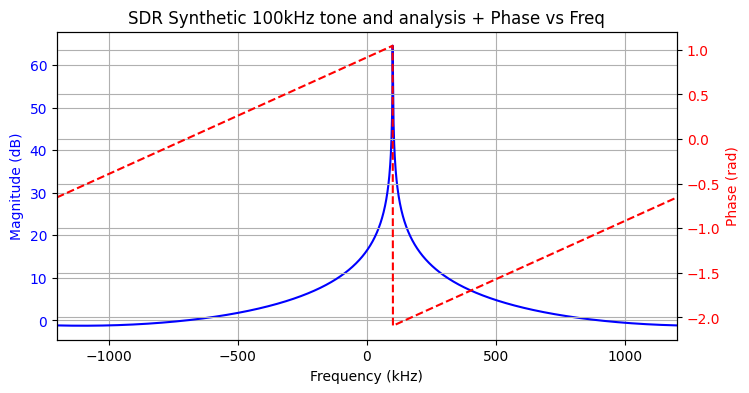

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 2.4e6 #sample rate ( 2.4 MHz)
f_tone = 100e3 #100 kHz tone
N = 2048 # Fundamental period

t = np.arange(N) / fs
signal = np.exp(2j * np.pi * f_tone * t)

fft = np.fft.fftshift(np.fft.fft(signal))

#fk = k / N * fs
freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

#Unwrap phase to prevent sudden jumps (degs)
phase = np.unwrap( (np.angle(fft)))

magnitude = 20*np.log10(np.abs(fft))

#fig and axisw
fig, ax1 = plt.subplots(figsize=(8,4))

#plot as dB in relation to kHz
ax1.plot(freqs/1e3, magnitude, color = 'b', label = 'Magnitude(dB)' )
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Magnitude (dB)', color = 'b')
ax1.tick_params(axis = 'y', labelcolor='b')

#center plot
ax1.set_xlim(-fs/(2*1e3), fs/(2*(1e3)))

#plot phase in relation to kHz
ax2 = ax1.twinx()
ax2.plot(freqs/1e3, phase, color = 'r', linestyle='--', label='Phase (rad)')
ax2.set_ylabel('Phase (rad)', color ='r')
ax2.tick_params(axis='y', labelcolor='r')


plt.title("SDR Synthetic 100kHz tone and analysis + Phase vs Freq")
ax1.grid(True)
ax2.grid(True)
plt.show()


## Synthetic 100kHz Tone with Noise

### Objective 
Add noise and compute fft of complex sinusoid

### Code:


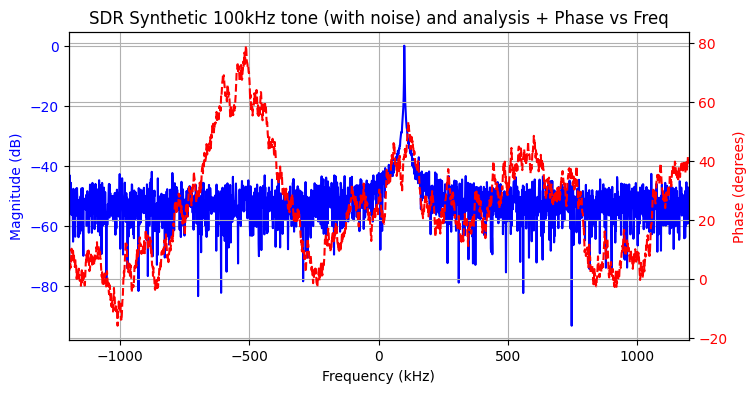

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fs = 2.4e6 #sample rate ( 2.4 MHz)
f_tone = 100e3 #100 kHz tone
N = 2048 # Fundamental period

t = np.arange(N) / fs
signal = np.exp(2j * np.pi * f_tone * t)

#gauss white noise
noise_power = 0.01
noise = np.sqrt(noise_power/2) * (np.random.randn(N) + 1j *np.random.randn(N))

#combine signals
rx_signal = signal + noise

fft_rx = np.fft.fftshift(np.fft.fft(rx_signal))

#fk = k / N * fs
freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))

#Unwrap phase to prevent sudden jumps (degs)
phase = np.unwrap( (180 / np.pi) * (np.angle(fft_rx)))

magnitude = 20*np.log10(np.abs(fft_rx) / np.max(np.abs(fft_rx)))

#fig and axisw
fig, ax1 = plt.subplots(figsize=(8,4))

#plot as dB in relation to kHz
ax1.plot(freqs/1e3, magnitude, color = 'b', label = 'Magnitude(dB)' )
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Magnitude (dB)', color = 'b')
ax1.tick_params(axis = 'y', labelcolor='b')

#center plot
ax1.set_xlim(-fs/(2*1e3), fs/(2*(1e3)))

#plot phase in relation to kHz
ax2 = ax1.twinx()
ax2.plot(freqs/1e3, phase, color = 'r', linestyle='--', label='Phase (rad)')
ax2.set_ylabel('Phase (degrees)', color ='r')
ax2.tick_params(axis='y', labelcolor='r')


plt.title("SDR Synthetic 100kHz tone (with noise) and analysis + Phase vs Freq")
ax1.grid(True)
ax2.grid(True)
plt.show()


## Measure SNR - Synthetic 100kHz Tone with Noise

### Objective 
Estimate SNR from noisy complex sinusoid and validate it against theoretical values

### Key Concepts
- gaussian noise modelling
-FFT and Windowing (hann)
-Power Spectral Density (PSD)
-SNR Estimation from frequncy bins

### Code:

Theoretical SNR = 20.0 dB
Estimated SNR = 44.7 dB


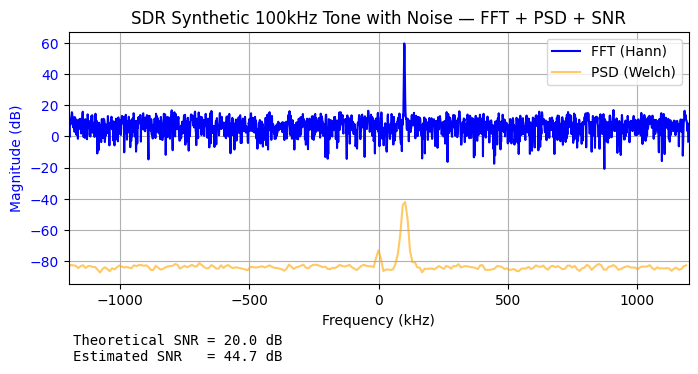

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, get_window

#------------------------------------
#Signal
#------------------------------------

fs = 2.4e6 #sample rate ( 2.4 MHz)
f_tone = 100e3 #100 kHz tone
N = 2048 # Fundamental period

t = np.arange(N) / fs

signal = np.exp(2j * np.pi * f_tone * t)

#------------------------------------
#gauss white noise
#------------------------------------
rng = np.random.default_rng(0)
noise_power = 0.01
noise = np.sqrt(noise_power/2) * (rng.standard_normal(N) + 1j *rng.standard_normal(N))
rx_signal = signal + noise





#------------------------------------
#combine signals
#------------------------------------

w = np.hanning(N)
fft_rx_w = np.fft.fftshift(np.fft.fft(rx_signal * w))
freqs = np.fft.fftshift(np.fft.fftfreq(N,1/fs))
mag_dbfs= 20*np.log10(np.abs(fft_rx_w) + 1e-15) 


#------------------------------------
#Power spectral density
#------------------------------------
f_psd, Pxx = welch(rx_signal, fs=fs, window='hann', nperseg = 256, noverlap=128, return_onesided=False, scaling='density')
f_psd = np.fft.fftshift(f_psd); Pxx = np.fft.fftshift(Pxx)
psd_db_hz =10*np.log10(Pxx + 1e-20) 

#------------------------------------
#SNR
#------------------------------------

# tone index ( neares bin to +f_tone after shift)
k0 = np.argmin(np.abs(freqs - f_tone))
bw_bins = 3
sig_bins = np.arange(k0-bw_bins, k0+bw_bins+1)

#total power from fft ( *parseval consisten if you divife by N^2 for power )
P_sig = np.sum(np.abs(fft_rx_w[sig_bins])**2)
mask = np.ones_like(fft_rx_w, dtype=bool); mask[sig_bins] = False
P_noise = np.sum(np.abs(fft_rx_w[mask])**2) / np.sum(mask) * len(sig_bins) # equalize to same bin amount

#snr theory
SNR_th_db = 10*np.log10(1/ noise_power)


SNR_est_dB = 10*np.log10(P_sig / P_noise + 1e-30)

print(f"Theoretical SNR = {SNR_th_db:.1f} dB")
print(f"Estimated SNR = {SNR_est_dB:.1f} dB")



#------------------------------------
# Plot
#------------------------------------
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(freqs/1e3, mag_dbfs, color='b', label='FFT (Hann)')
ax1.plot(f_psd/1e3, psd_db_hz, color='orange', alpha=0.6, label='PSD (Welch)')
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Magnitude (dB)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(-fs/(2*1e3), fs/(2*1e3))
plt.title("SDR Synthetic 100kHz Tone with Noise — FFT + PSD + SNR")
ax1.grid(True)
ax1.legend()

snr_text = f"Theoretical SNR = {SNR_th_db:.1f} dB\nEstimated SNR   = {SNR_est_dB:.1f} dB"

# leave room at bottom for caption
plt.subplots_adjust(bottom=0.25)

# place caption under axes
plt.figtext(
    0.13, 0.05, snr_text,
    fontsize=10, ha='left', va='bottom', family='monospace'
)

plt.savefig("snr_demo.png", dpi=200, bbox_inches='tight')
plt.show()

## Finite Impulse Response Filter

### Theory

$$
y[n] = \sum_{k=0}^{M -1} b_{k}\cdot x[n-k] = \sum_{k=0}^{M - 1} x[n-k] \cdot h[n] , N = M - 1
$$

where :

- $h[k]$ : filter coefficients (defines filter shape or response) 
- $M$ : Number of coefficients = "filter order (N)" - 1
- $x[n]$ : Input samples
- $y[n]$ : filtered output

#### Think of $h[k]$ as allowed time 'window' 



where in frequency (much more simple operation)

$$
Y(\omega) = X(\omega) \cdot H(\omega)
$$

The goal is to design H(f) as to remove all unwanted noise and keep our main signal.

### Objective

Demonstrate FIR Filtering by removing out-of-band noise (~100kHz tone)

### Concepts
- Fir Design with 'scipy.signal.firwin'
- Frequency-domain interpretation of filtering
- SNR improvement and bandwidth tradeoffs

### Results
| Metric    | Before | After|
|:-----------:|:-----------:|:----------:|
| Estimated SNR | 44.7 dB | 59.6 dB |



#### Some sources 
- https://www.precisionaudioservices.com/blog/conceptual-explanation-o../measure_snr/snr_demo.pngf-fir-filters
- https://en.wikipedia.org/wiki/Finite_impulse_response
- https://cycling74.com/tutorials/demystifying-digital-filters-part-1

### Code:


In [5]:
"""

easiest way to design h[k] : 
Window Method (hann)

Generates band-pass FIR centered around 100 kHz

window_method.py

"""

from scipy.signal import firwin

numtaps = 101     #number of coefficients ( filter length)
lowcut  = 80e3    #lower cut off frequency (80kHz)
highcut = 120e3   #Uppoer cut off frequency (120kHZ)
fs      = 2.4e6   #sample rate (2.4MHz)


taps = firwin (
    numtaps,
    [lowcut, highcut],
    pass_zero=False,
    fs=fs,
    window='hann')

Theoretical SNR = 20.0 dB
Estimated SNR = 59.6 dB
Filter bandwidth: 40.0 kHz
Main lobe width: ~34.13 FFT bins
Filter bandwidth: 40.0 kHz
Main lobe width: ~34.13 FFT bins


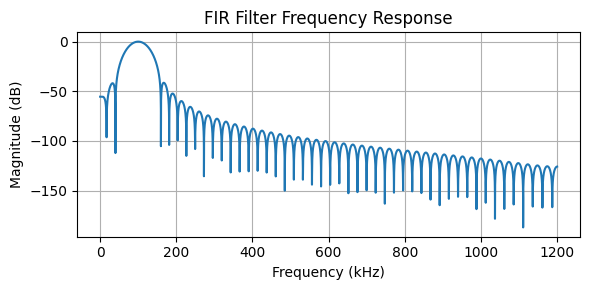

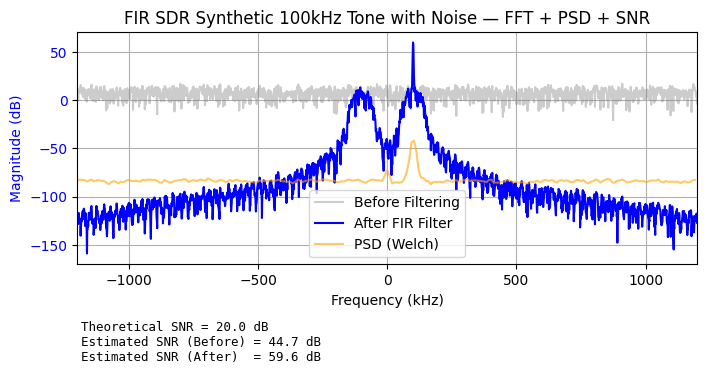

In [22]:
"""
FIR Filter
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, get_window

from scipy.signal import lfilter

#------------------------------------
#Signal
#------------------------------------

fs = 2.4e6 #sample rate ( 2.4 MHz)
f_tone = 100e3 #100 kHz tone
N = 2048 # Fundamental period

t = np.arange(N) / fs

signal = np.exp(2j * np.pi * f_tone * t)

#------------------------------------
#gauss white noise (AWGN)
#------------------------------------
rng = np.random.default_rng(0)
noise_power = 0.01
noise = np.sqrt(noise_power/2) * (rng.standard_normal(N) + 1j *rng.standard_normal(N))
rx_signal = signal + noise


#------------------------------------
#Filtered signal (FIR Band-pass) -- look at window_method.py
#------------------------------------
from scipy.signal import firwin

numtaps = 101     #number of coefficients ( filter length)
lowcut  = 80e3    #lower cut off frequency (80kHz)
highcut = 120e3   #Uppoer cut off frequency (120kHZ)
fs      = 2.4e6   #sample rate (2.4MHz)


taps = firwin (
    numtaps,
    [lowcut, highcut],
    pass_zero=False,
    fs=fs,
    window='hann')

filtered_signal = lfilter(taps, 1.0, rx_signal)



#------------------------------------
#combine signals
#------------------------------------

w = np.hanning(N)
fft_rx_w_filtered = np.fft.fftshift(np.fft.fft(filtered_signal * w))
freqs = np.fft.fftshift(np.fft.fftfreq(N,1/fs))
mag_dbfs= 20*np.log10(np.abs(fft_rx_w_filtered) + 1e-15) 

#------------------------------------
#unfiltered signal for comparison
#------------------------------------

fft_rx_w = np.fft.fftshift(np.fft.fft(rx_signal * w))
mag_dbfs_before = 20*np.log10(np.abs(fft_rx_w) + 1e-15)


#------------------------------------
#Power spectral density
#------------------------------------
f_psd, Pxx = welch(rx_signal, fs=fs, window='hann', nperseg = 256, noverlap=128, return_onesided=False, scaling='density')
f_psd = np.fft.fftshift(f_psd); Pxx = np.fft.fftshift(Pxx)
psd_db_hz =10*np.log10(Pxx + 1e-20) 

#------------------------------------
#Unfiltered SNR
#------------------------------------

# tone index ( neares bin to +f_tone after shift)
k0 = np.argmin(np.abs(freqs - f_tone))
bw_bins = 3
sig_bins = np.arange(k0-bw_bins, k0+bw_bins+1)


fft_rx_w_unfiltered = np.fft.fftshift(np.fft.fft(rx_signal * w))
P_sig_before = np.sum(np.abs(fft_rx_w_unfiltered[sig_bins])**2)
mask_before = np.ones_like(fft_rx_w_unfiltered, dtype=bool); mask_before[sig_bins] = False
P_noise_before = np.sum(np.abs(fft_rx_w_unfiltered[mask_before])**2) / np.sum(mask_before) * len(sig_bins)
SNR_est_before_dB = 10*np.log10(P_sig_before / P_noise_before + 1e-30)




#------------------------------------
#Filtered SNR
#------------------------------------


#total power from fft-filtered
P_sig = np.sum(np.abs(fft_rx_w_filtered[sig_bins])**2)
mask = np.ones_like(fft_rx_w_filtered, dtype=bool); mask[sig_bins] = False
P_noise = np.sum(np.abs(fft_rx_w_filtered[mask])**2) / np.sum(mask) * len(sig_bins) # equalize to same bin amount

#snr theory - general
SNR_th_db = 10*np.log10(1/ noise_power)

#snr after filtering
SNR_est_after_dB = 10*np.log10(P_sig / P_noise + 1e-30)

print(f"Theoretical SNR = {SNR_th_db:.1f} dB")
print(f"Estimated SNR = {SNR_est_after_dB:.1f} dB")

#------------------------------------
# Bandwidth
#------------------------------------

bw = highcut - lowcut
print(f"Filter bandwidth: {bw/1e3:.1f} kHz")
print(f"Main lobe width: ~{bw/fs*N:.2f} FFT bins")



#------------------------------------
# filter shape Plot
#------------------------------------

from scipy.signal import freqz
bw = highcut - lowcut
print(f"Filter bandwidth: {bw/1e3:.1f} kHz")
print(f"Main lobe width: ~{bw/fs*N:.2f} FFT bins")
w_hz, h = freqz(taps, worN=8000, fs=fs)
plt.figure(figsize=(6,3))
plt.plot(w_hz/1e3, 20*np.log10(np.abs(h)))
plt.title('FIR Filter Frequency Response')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.tight_layout()
plt.show()


#------------------------------------
# Plot
#------------------------------------
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(freqs/1e3, mag_dbfs_before, color='gray', alpha=0.4, label='Before Filtering')
ax1.plot(freqs/1e3, mag_dbfs, color='b', label='After FIR Filter')
ax1.plot(f_psd/1e3, psd_db_hz, color='orange', alpha=0.6, label='PSD (Welch)')
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Magnitude (dB)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(-fs/(2*1e3), fs/(2*1e3))
plt.title("FIR SDR Synthetic 100kHz Tone with Noise — FFT + PSD + SNR")
ax1.grid(True)
ax1.legend()

snr_text = (
    f"Theoretical SNR = {SNR_th_db:.1f} dB\n"
    f"Estimated SNR (Before) = {SNR_est_before_dB:.1f} dB\n"
    f"Estimated SNR (After)  = {SNR_est_after_dB:.1f} dB"
)
plt.subplots_adjust(bottom=0.3)
plt.figtext(
    0.13, 0.05, snr_text,
    fontsize=9, ha='left', va='bottom', family='monospace'
)

plt.savefig("snr_demo.png", dpi=200, bbox_inches='tight')
plt.show()

### Frequency-Domain Interpretation
The gray trace shows the noisy unfiltered spectrum.  
The blue trace shows the signal after FIR band-pass filtering (80–120 kHz).  
The orange line represents the Power Spectral Density estimate using Welch averaging.


## Infinite Impulse Response Filter

### Theory
Compared to FIR Filters, IIR is more enticing due to the calculation being "budget friendly" computationally. By implementing a feedback loop, the filter can correct itself gradually without as much overhead that the FIR filter employs. 

It can be described by:
$$
y[n] = \sum_{k=0}^{M} b_{k} x[n-k] - \sum_{k=1}^{N} a_{k} y[n-k]
$$

Where:
- x[n] is the input signal
- y[n] is the output
- $b_{k}$ is the feed-forward coefficient
- $a_{k}$ is the feed-back coefficient


Where the biggest difference compared to the FIR filter is the use of previous y[n-1] to subtract from the initial filter.FIR only uses $b_{k}$, IIR uses both $b_{k}$ and $a_{k}$.

The function is called Infinite Impulse because it can continue decaying for ever (in theory).

### Some Sources:
- https://courses.grainger.illinois.edu/ECE401/fa2023/slides/lec28.pdf
  
### Code:


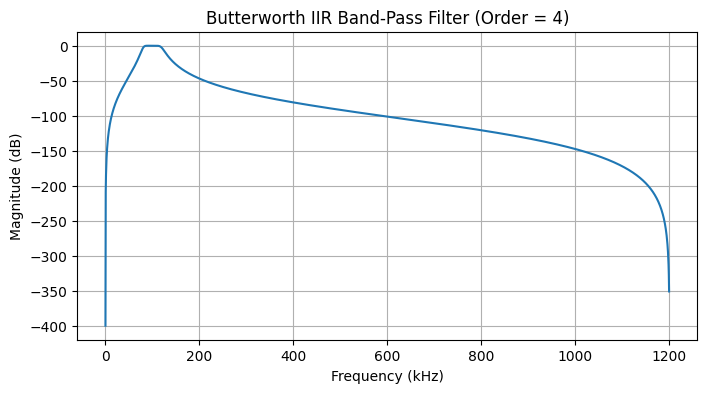

In [20]:
"""
Butterworth band-pass filter

Great for maximally flat frequency response, no ripple
"""

from scipy.signal import butter, sosfilt, sosfreqz
import matplotlib.pyplot as plt
import numpy as np

#-----------------------------
#Params
#-----------------------------
fs = 2.4e6 # 2.4 MHz Sampling rate
lowcut = 80e3 # 80 kHz Lower cut-off frequency
highcut = 120e3 # 120kHz Upper cutoff frequency
order = 4 # Filter order controlling steepness

#-----------------------------
#Filter
#-----------------------------
sos = butter(order, [lowcut,highcut], btype='bandpass', fs=fs, output='sos')

#-----------------------------
#Plot
#-----------------------------

w, h = sosfreqz(sos, worN=2048, fs=fs)

plt.figure(figsize=(8, 4))
plt.plot(w/1e3, 20 * np.log10(np.abs(h) + 1e-20)) #prevent divide by zero error
plt.title(f"Butterworth IIR Band-Pass Filter (Order = {order})")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)
plt.show()

Theoretical SNR = 20.0 dB
Estimated SNR = 59.9 dB
Filter bandwidth: 40.0 kHz
Main lobe width: ~34.13 FFT bins


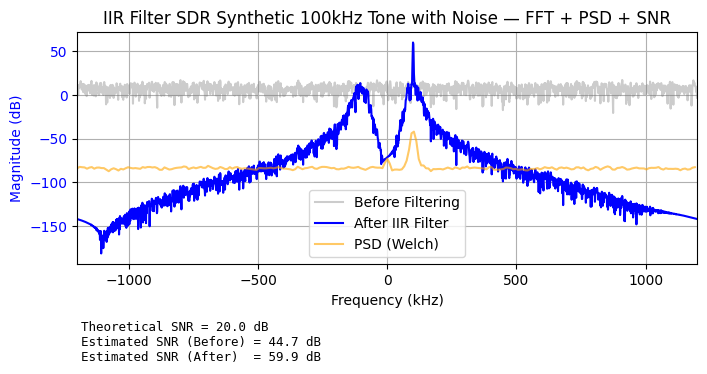

In [24]:
"""
IIR Filter
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, get_window

from scipy.signal import lfilter

#------------------------------------
#Signal
#------------------------------------

fs = 2.4e6 #sample rate ( 2.4 MHz)
f_tone = 100e3 #100 kHz tone
N = 2048 # Fundamental period

t = np.arange(N) / fs

signal = np.exp(2j * np.pi * f_tone * t)

#------------------------------------
#gauss white noise (AWGN)
#------------------------------------
rng = np.random.default_rng(0)
noise_power = 0.01
noise = np.sqrt(noise_power/2) * (rng.standard_normal(N) + 1j *rng.standard_normal(N))
rx_signal = signal + noise


#------------------------------------
#Filtered signal (IIR Band-pass) 
#------------------------------------
from scipy.signal import butter, sosfilt, sosfreqz

fs = 2.4e6 # 2.4 MHz Sampling rate
lowcut = 80e3 # 80 kHz Lower cut-off frequency
highcut = 120e3 # 120kHz Upper cutoff frequency
order = 4 # Filter order controlling steepness


sos = butter(order, [lowcut,highcut], btype='bandpass', fs=fs, output='sos')


filtered_signal = sosfilt(sos, rx_signal)



#------------------------------------
#combine signals
#------------------------------------

w = np.hanning(N)
fft_rx_w_filtered = np.fft.fftshift(np.fft.fft(filtered_signal * w))
freqs = np.fft.fftshift(np.fft.fftfreq(N,1/fs))
mag_dbfs= 20*np.log10(np.abs(fft_rx_w_filtered) + 1e-15) 

#------------------------------------
#unfiltered signal for comparison
#------------------------------------

fft_rx_w = np.fft.fftshift(np.fft.fft(rx_signal * w))
mag_dbfs_before = 20*np.log10(np.abs(fft_rx_w) + 1e-15)


#------------------------------------
#Power spectral density
#------------------------------------
f_psd, Pxx = welch(rx_signal, fs=fs, window='hann', nperseg = 256, noverlap=128, return_onesided=False, scaling='density')
f_psd = np.fft.fftshift(f_psd); Pxx = np.fft.fftshift(Pxx)
psd_db_hz =10*np.log10(Pxx + 1e-20) 

#------------------------------------
#Unfiltered SNR
#------------------------------------

# tone index ( neares bin to +f_tone after shift)
k0 = np.argmin(np.abs(freqs - f_tone))
bw_bins = 3
sig_bins = np.arange(k0-bw_bins, k0+bw_bins+1)


fft_rx_w_unfiltered = np.fft.fftshift(np.fft.fft(rx_signal * w))
P_sig_before = np.sum(np.abs(fft_rx_w_unfiltered[sig_bins])**2)
mask_before = np.ones_like(fft_rx_w_unfiltered, dtype=bool); mask_before[sig_bins] = False
P_noise_before = np.sum(np.abs(fft_rx_w_unfiltered[mask_before])**2) / np.sum(mask_before) * len(sig_bins)
SNR_est_before_dB = 10*np.log10(P_sig_before / P_noise_before + 1e-30)




#------------------------------------
#Filtered SNR
#------------------------------------


#total power from fft-filtered
P_sig = np.sum(np.abs(fft_rx_w_filtered[sig_bins])**2)
mask = np.ones_like(fft_rx_w_filtered, dtype=bool); mask[sig_bins] = False
P_noise = np.sum(np.abs(fft_rx_w_filtered[mask])**2) / np.sum(mask) * len(sig_bins) # equalize to same bin amount

#snr theory - general
SNR_th_db = 10*np.log10(1/ noise_power)

#snr after filtering
SNR_est_after_dB = 10*np.log10(P_sig / P_noise + 1e-30)

print(f"Theoretical SNR = {SNR_th_db:.1f} dB")
print(f"Estimated SNR = {SNR_est_after_dB:.1f} dB")

#------------------------------------
# Bandwidth
#------------------------------------

bw = highcut - lowcut
print(f"Filter bandwidth: {bw/1e3:.1f} kHz")
print(f"Main lobe width: ~{bw/fs*N:.2f} FFT bins")





#------------------------------------
# Plot
#------------------------------------
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(freqs/1e3, mag_dbfs_before, color='gray', alpha=0.4, label='Before Filtering')
ax1.plot(freqs/1e3, mag_dbfs, color='b', label='After IIR Filter')
ax1.plot(f_psd/1e3, psd_db_hz, color='orange', alpha=0.6, label='PSD (Welch)')
ax1.set_xlabel('Frequency (kHz)')
ax1.set_ylabel('Magnitude (dB)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(-fs/(2*1e3), fs/(2*1e3))
plt.title("IIR Filter SDR Synthetic 100kHz Tone with Noise — FFT + PSD + SNR")
ax1.grid(True)
ax1.legend()

snr_text = (
    f"Theoretical SNR = {SNR_th_db:.1f} dB\n"
    f"Estimated SNR (Before) = {SNR_est_before_dB:.1f} dB\n"
    f"Estimated SNR (After)  = {SNR_est_after_dB:.1f} dB"
)
plt.subplots_adjust(bottom=0.3)
plt.figtext(
    0.13, 0.05, snr_text,
    fontsize=9, ha='left', va='bottom', family='monospace'
)

plt.show()

### Rewritten using dsp_utils tools


Theoretical SNR = 20.0dB
Estimated SNR (before) = 44.6 dB
Estimated SNR (after) = 59.2 dB


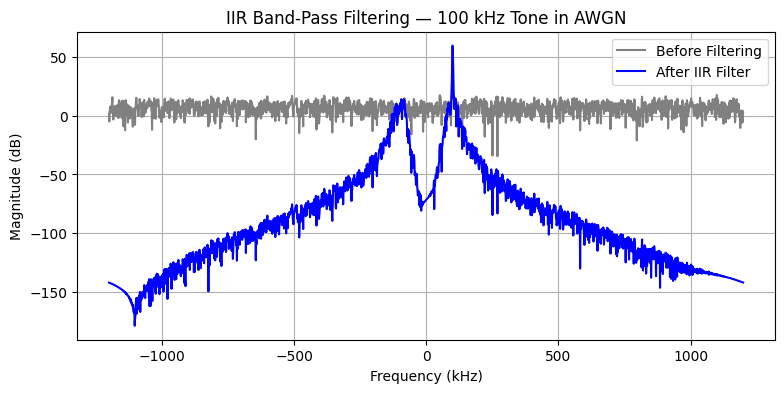

In [1]:
import sys, os
sys.path.append(os.path.abspath("/home/ostrich/Dev/sdr_dsp_labs"))
from dsp_utils import (
    generate_tone,
    apply_bandpass,
    compute_fft,
    plot_spectrum,
    estimate_snr
)
import matplotlib.pyplot as plt
import numpy as np

#-------------------------
#Params
#-------------------------
fs = 2.4e6 #2.4MHz sample rate
f_tone = 100e3 #100 kHz tone
snr_db = 20 #theoretical dB SNR

#-------------------------
# IIR Config
#-------------------------
lowcut = 80e3
highcut = 120e3
order = 4

#-------------------------
# Signal + AWGN
#-------------------------
sig, rx = generate_tone(f_tone=f_tone, fs=fs, snr_db=snr_db)

#-------------------------
# Apply IIR filter
#-------------------------
filtered = apply_bandpass(rx, fs=fs,lowcut=lowcut, highcut=highcut, order=order, method='iir')

#-------------------------
# Computer FFT Magnitudes
#-------------------------
freqs, mag_before = compute_fft(rx,fs)
_, mag_after = compute_fft(filtered,fs)

#-------------------------
# Estimate SNR Improvement
#-------------------------
snr_before, snr_after= estimate_snr(rx, filtered, fs, f_tone=f_tone)
print(f"Theoretical SNR = {snr_db:.1f}dB")
print(f"Estimated SNR (before) = {snr_before:.1f} dB")
print(f"Estimated SNR (after) = {snr_after:.1f} dB")

#-------------------------
# plot
#-------------------------
plt.figure(figsize=(9,4))
plot_spectrum(freqs, mag_before, label='Before Filtering', color='gray')
plot_spectrum(freqs, mag_after, label='After IIR Filter', color='b')

plt.title("IIR Band-Pass Filtering — 100 kHz Tone in AWGN")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)

plt.show()


## Window & Spectral Leakage

### Theory

We can recall from the from the theory section of FIR that the relationship between our intput $x(\omega)$ and our output $y(\omega)$ was the transfer fuction  $h(\omega)$. When windowing, this operation becomes 'flipped', where we are only permitted to multiply h and x in the time domain;  rather than when filtering happens  in the frequency domain. 

When we observe a finite-lenght signal, x[n], this operation is equivalent to multiplying by a continuous signal by a rectangular window $w[n]$. In frequency domain, this is a convolution between the ideal spectrum and the Fourier transform of the window itself. This can be confusing, 

This convolution, however, introduces spectral leakage, where energy from one frequency 'leaks' into other frequencies, forming side lobes around the main tone. By applying different windowing techniques  ( Han, Hamming, Blackman, etc...) we can reduce the amplitude of the side lobes at the cost of widening the main lobe. The choice of the window represents teh trade-off between frequency resolution ( narrowing the main lobe) and leakage suppression (low side lobes).

### Code:

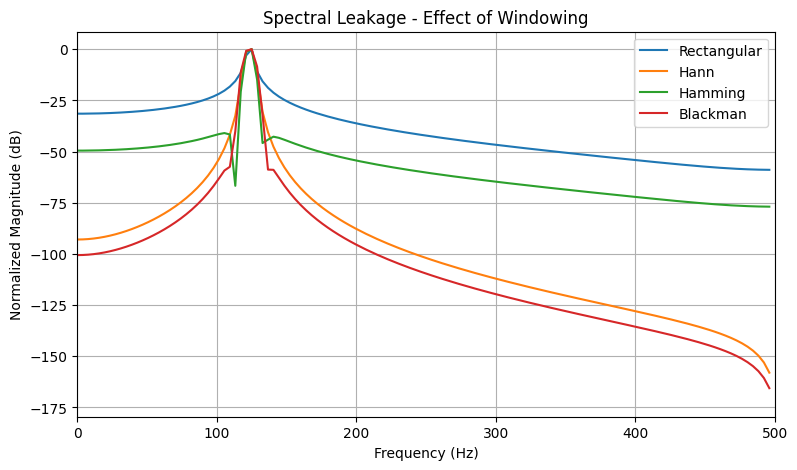

Peak Sidelobe Level (dB relative to main lobe):
Rectangular : -26.50 dB
Hann        : -70.35 dB
Hamming     : -44.89 dB
Blackman    : -78.37 dB


In [1]:
import sys, os
sys.path.append(os.path.abspath("/home/ostrich/Dev/sdr_dsp_labs"))
from dsp_utils import compute_fft, plot_spectrum, measure_psl
import numpy as np
import matplotlib.pyplot as plt

#-------------------------
#Params
#-------------------------

fs = 1000 # 1kHz Sample rate
f_tone = 123.4 # Choose tone not aligned with fft bins
N = 256# Small sample to exaggerate leakage

t = np.arange(N) / fs
signal = np.sin(2*np.pi*f_tone*t)

#-------------------------
#Define Window Types
#-------------------------
windows = {
    "Rectangular": np.ones(N),
    "Hann": np.hanning(N),
    "Hamming": np.hamming(N),
    "Blackman": np.blackman(N),
}

#-------------------------
#Compute FFT For Each Kind of Window
#-------------------------
plt.figure(figsize=(9,5))
for name, w in windows.items():
    freqs, mag_db = compute_fft(signal,fs, window = w)

    plt.plot(freqs, mag_db, label=name)

#-------------------------
#Plot
#-------------------------

plt.title("Spectral Leakage - Effect of Windowing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Magnitude (dB)")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()

#-------------------------
#Measure Leakage for Each Window
#-------------------------

print("Peak Sidelobe Level (dB relative to main lobe):")
for name, w in windows.items():
    psl_db = measure_psl(signal, fs, w, guard_bins=10)
    print(f"{name:12s}: {psl_db:6.2f} dB")

Different windowing functions offer trade-offs between frequency resolution and leakage suppression.
A rectangular window provides the narrowest main lobe, allowing fine frequency resolution, but produces large side lobes that cause severe spectral leakage ( -26.50 dB).
The Hann and Hamming windows taper smoothly to zero at the edges, which reduces the side-lobe level and leakage at the cost of slightly widening the main lobe.
Finally, the Blackman window offers excellent leakage suppression—with side lobes over 70 dB below the main tone—but its main lobe is the widest, making it less effective at resolving closely spaced frequencies.
In short, each window balances clarity and precision differently: sharper windows reveal detail, while smoother ones suppress interference.

## Spectral Estimation & Welch Power Spectral Density
### Theory
If we take a single FFT, it will show the frequency of one single time segment. This reading can be **noisy and unstable** . 
This happens because each FFT grame captures a small random snapshot of noise -so the spectral power will vary wildly from frame to frame. 

The **Welch Method** solves this by splitting the signal into overlapping segments, applying a window to each, taking the FFT, and then **averaging the power spectra** of all segments. This averaging reduces noise variance roughly by 1/N, where N is the number of averaged segments. 

The trade offs: 
- Longer segments results in higher frequency resolution but fewer averages ( noisier estimates).
- Shorter segments have a lower, smoother resolution with a more stable estimate.

Applying Welch averaging to an SDR spectrum display will make it smooth rather than flickering frame to frame

### Code :

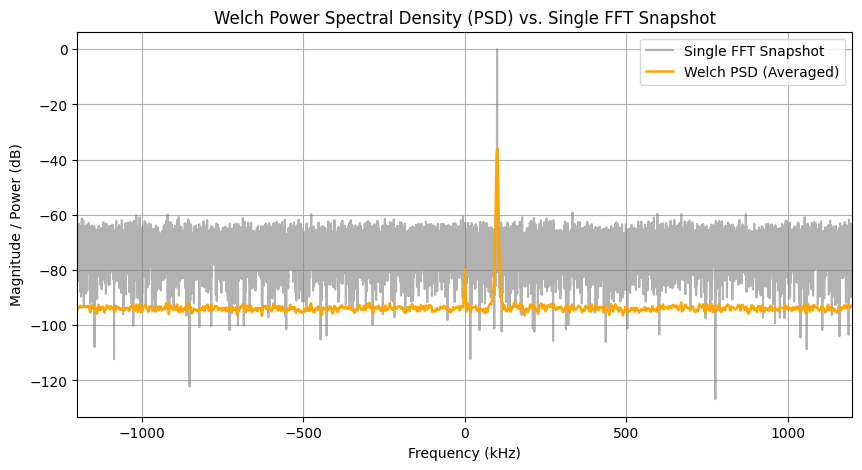

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, get_window

#-------------------------
#Params
#-------------------------
fs = 2.4e6     # Sample Rate (2.4MHz )
f_tone = 100e3 # 100 kHz  tone
N = 16384      # samples
t = np.arange(N) / fs 

#tone + noise
rng = np.random.default_rng(0)
noise_power = 0.001
signal = np.exp(2j *np.pi *f_tone *t) 
rx_signal = signal + np.sqrt(noise_power/2)*(rng.standard_normal(N) + 1j * rng.standard_normal(N))

#-------------------------
#Single FFT with no Averaging
#-------------------------\
window = get_window('hann', N)
fft_vals = np.fft.fftshift(np.fft.fft(rx_signal * window))
freqs = np.fft.fftshift(np.fft.fftfreq(N,1/fs))
mag_db = 20*np.log10(np.abs(fft_vals)/np.max(np.abs(fft_vals))+1e-12)

#-------------------------
#Welch PSD Averaging
#-------------------------
f_psd, Pxx = welch(rx_signal, fs=fs, window ='hann', nperseg=1024, noverlap=512, scaling='density')
Pxx_db = 10*np.log10(Pxx + 1e-15)

#-------------------------
#Plot comparison
#-------------------------
plt.figure(figsize=(10,5))
plt.plot(freqs/1e3, mag_db, label='Single FFT Snapshot', color='gray', alpha=0.6)
plt.plot(np.fft.fftshift(f_psd)/1e3, np.fft.fftshift(Pxx_db), label='Welch PSD (Averaged)', color='orange', linewidth=1.8)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude / Power (dB)")
plt.title("Welch Power Spectral Density (PSD) vs. Single FFT Snapshot")
plt.legend()
plt.grid(True)
plt.xlim(-fs/(2*1e3), fs/(2*1e3))
plt.show()

Both represent the same underlying signal, but Welch averaging reduces the random noise floor while preserving the tone’s peak power.

In SDR receivers, this principle underlies waterfall plots and spectrum analyzers — they don’t show raw FFTs, but rather continuously averaged PSDs to provide a consistent visual display.

## Resolution Bandwidth (RBW) & Segment Length Trade-Off

### Theory

From the previous section, the characteristic that determined either smoothness or resolution was the **Segment length $(N_{seg})$**. This changes the width of each FFT Bin - aka **Resolution Bandwidth** . The RBW describes the smallest frequency that each segment can represent :
$$ RBW = \frac{f_{s}}{N_{seg}} $$

When choosing RBW, a decision has to be made : slower, detailed readings or visually smooth, less accurate readings. 


### Code

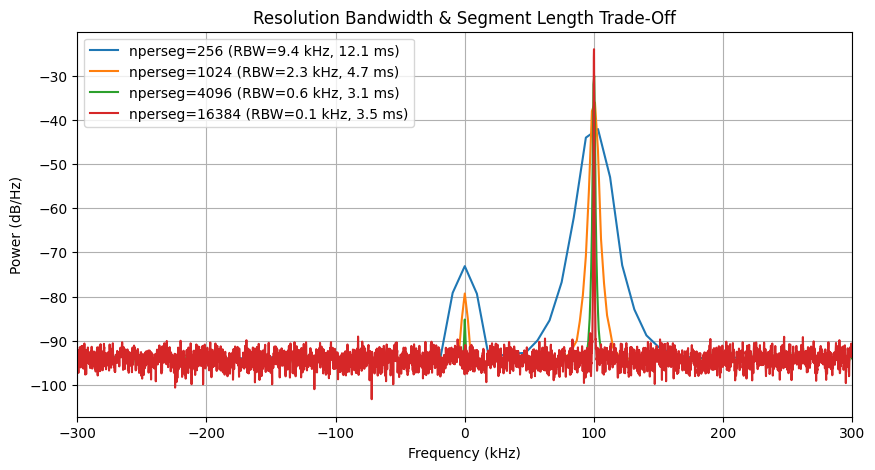

Segment Length Timing Comparison:
nperseg	RBW (Hz)	Time (ms)
256	    9375.0	   12.14
1024	    2343.8	    4.72
4096	     585.9	    3.08
16384	     146.5	    3.54


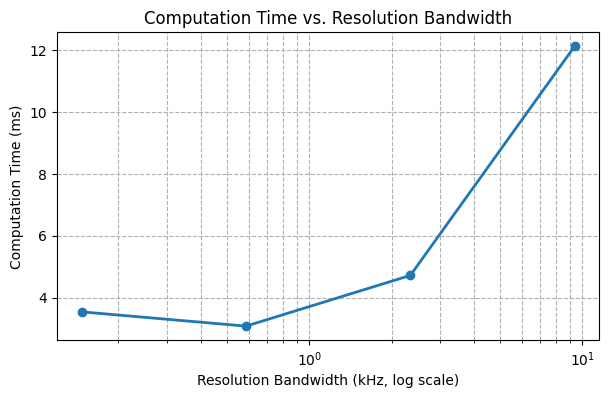

,nperseg,RBW_kHz,Time_ms
0,256,9.375000,12.139744
1,1024,2.343750,4.717232
2,4096,0.585938,3.075433
3,16384,0.146484,3.537736


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, get_window
import time
import pandas as pd


#Timing function for comparison
def time_function(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed

#-------------------------
#Params
#-------------------------
fs     = 2.4e6   #2.4 MHz sample rate
f_tone = 100e3   #100kHz Tone
N      = 65536   # Very large length
t = np.arange(N) / fs

#AWGN
rng = np.random.default_rng(0)
noise_power = 0.001
signal = np.exp(2j * np.pi * f_tone * t)
rx_signal = signal + np.sqrt(noise_power / 2) * (rng.standard_normal(N) + 1j* rng.standard_normal(N))

#-------------------------
#Welch PSD 
#-------------------------
segment_lengths = [256, 1024, 4096, 16384]
plt.figure(figsize=(10,5))

timing_results = []

for seg in segment_lengths:
    # Time the Welch PSD call
    (f_psd, Pxx), elapsed = time_function(
        welch, rx_signal, fs, 'hann', seg, seg//2, scaling='density'
    )
    
    Pxx_db = 10*np.log10(Pxx + 1e-15)
    plt.plot(np.fft.fftshift(f_psd)/1e3, np.fft.fftshift(Pxx_db),
             label=f"nperseg={seg} (RBW={fs/seg/1e3:.1f} kHz, {elapsed*1e3:.1f} ms)")
    
    timing_results.append((seg, fs/seg, elapsed))

plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (dB/Hz)")
plt.title("Resolution Bandwidth & Segment Length Trade-Off")
plt.grid(True)
plt.legend()
plt.xlim(-300, 300)
plt.show()

#-------------------------
#Time comparison
#-------------------------

print("Segment Length Timing Comparison:")
print("nperseg\tRBW (Hz)\tTime (ms)")
for seg, rbw, elapsed in timing_results:
    print(f"{seg}\t{rbw:10.1f}\t{elapsed*1e3:8.2f}")

# Convert timing results to DataFrame for plotting
df = pd.DataFrame(timing_results, columns=["nperseg", "RBW_Hz", "Time_s"])
df["RBW_kHz"] = df["RBW_Hz"] / 1e3
df["Time_ms"] = df["Time_s"] * 1e3

# Plot RBW vs. Time
plt.figure(figsize=(7,4))
plt.plot(df["RBW_kHz"], df["Time_ms"], 'o-', lw=2)
plt.xscale('log')
plt.xlabel("Resolution Bandwidth (kHz, log scale)")
plt.ylabel("Computation Time (ms)")
plt.title("Computation Time vs. Resolution Bandwidth")
plt.grid(True, which='both', ls='--')
plt.show()


display(df[["nperseg", "RBW_kHz", "Time_ms"]])




From the graphs, it would be wise to choose a segment length larger that 1024 bits but smaller than 4096 bits for the most balanced expereince.  This configuration will yield usable data ( decent resolution aka smaller RBW) while not incurring significant delay. 

## Signal-to-Noise Ratio (SNR) & Noise Analysis ( Explanation)

While covered before in passing, I felt it worth pausing to go more in depth on what noise and **SNR** meant and why it was important to our filtering sections. 


### Theory

In any signal acquisition system, from SDR to radar or microphones, noise is inevitable. The **Signal-to-Noise Ratio (SNR)** identifies how strong a signal is compared to the noise around: 
$$ 
SNR_{linear} = \frac{P_{signal}}{P_{noise}}
$$
$$
SNR_{dB} = 10\log_{10}(\frac{P_{signal}}{P_{noise}})
$$

Where:

- $P_{signal}$ is the power of the signal we want to measure
- $P_{noise}$ is the power of the noise of the environment

When the digital filters were applied, $h(n)$ / $h(\omega)$ was designed to remove as much noise power as possible without distorting the main signal. Contrasting both **IIR** and **FIR** in this role:

- **FIR** filters provided a stable, linear-phase filter but require more coefficients
- **IIR** filters offered sharper roll-off with less coefficients, but at the cost of phase distortion

A common way to estimate SNR Numerically:



$$
SNR = 10\log_{10}(\frac{mean(x_{signal}^2)}{mean(x_{noise}^2)})
$$

## Noise Characterization in Frequency Domain

### Theory

In the SNR Analysis section, SNR was measured in the time domain, and we analyzed how filters impact the SNR in the same domain. 

In most real world systems, SNR is measured in the frequency domain instead, because there is more meaningful data to be pulled from a FFT. This is because the signal can be separate into different spectral components. 

When we take a FFT of a noisy signal, each bin represents energy over a small bandwidth, which is equal to the Resolution bandwidth: 

$$
RBW = \frac{f_s}{N_{FFT}}
$$

To measure SNR in the frequency domain, we first need to find the power of both the signal and the noise. We do this by **summing the power spectral density (PSD) across the signal band ($f \in signal\space band$)** and compare it to the **noise floor accross the rest of the spectrum ($f \notin signal \space band$)**:

$$
P_{signal} = \sum_{f\in signal\space band}|X(f)|^2 ,\space \space P_{noise}=\sum_{f\notin signal\space band}|X(f)|^2
$$
$$
SNR_{dB} = 10\log_{10}(\frac{P_{signal}}{P_{noise}})
$$

This is the same concept used within spectrum analyzers and SDR Software, where the noise floor is typicall expressed as **dB/Hz**.
In this approach, both total noise power and SNR depend on:

- The **window type**
- The **FFT Length** (RBW)
- The **averaging** method (Welch)

### Code: 

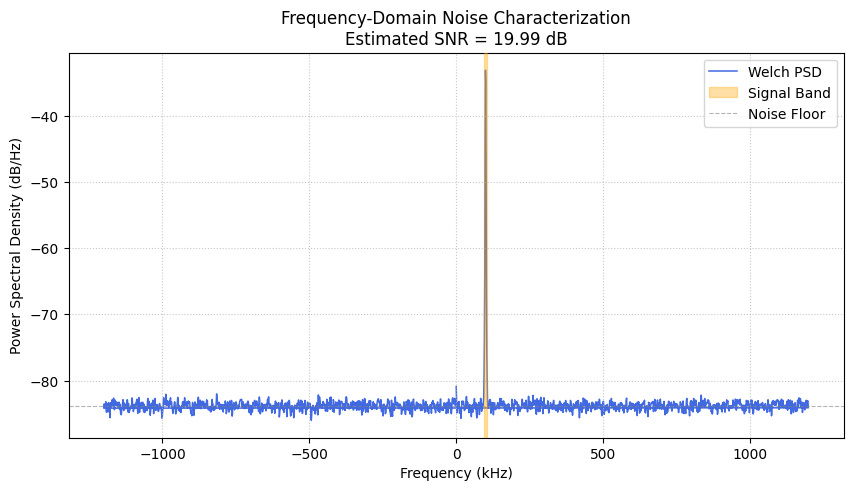

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch



#-------------------------
#Params
#-------------------------
fs     = 2.4e6
f_tone = 100e3 
N      = 65536
t      = np.arange(N) / fs



#-------------------------
#Signal + Noise Generation
#-------------------------
rng = np.random.default_rng(0)
noise_power = 0.01
signal = np.exp(2j * np.pi * f_tone * t)
rx_signal = signal + np.sqrt(noise_power / 2) * (rng.standard_normal(N) + 1j*rng.standard_normal(N))


#-------------------------
#Welch PSD
#-------------------------
f_psd, Pxx = welch(rx_signal, fs = fs, window = 'hann', nperseg = 2048, noverlap = 1024, scaling = 'density')
Pxx_db = 10* np.log10(Pxx + 1e-20)


#-----------------------------------
#Estimate Signal Band + Noise Floor (See theory)
#-----------------------------------
#define + / - 5 kHz around tone as "signal band"
band_mask = (f_psd > f_tone - 5e3) & (f_psd < f_tone + 5e3)
noise_mask = ~band_mask

P_sig = np.sum(Pxx[band_mask])
P_noise = np.sum(Pxx[noise_mask])
SNR_est_db = 10*np.log10(P_sig/P_noise + 1e-20)

#-------------------------
#Plot
#-------------------------
plt.figure(figsize=(10,5))
plt.plot(f_psd/1e3, Pxx_db, color='royalblue', lw=1.1, zorder=1, label="Welch PSD")
plt.axvspan((f_tone-5e3)/1e3, (f_tone+5e3)/1e3,
            color='orange', alpha=0.35, zorder=3, label='Signal Band')

plt.axhline(np.median(Pxx_db), color='gray', ls='--', lw=0.8, alpha=0.6, label='Noise Floor')
plt.title(f"Frequency-Domain Noise Characterization\nEstimated SNR = {SNR_est_db:.2f} dB")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.grid(True, which='both', ls=':', alpha=0.7)
plt.legend(frameon=True)
plt.show()

## Quantization Noise & Effective Number of Bits (ENOB)

### Theory
When an analog signal passes through an **Analog-to-Digital Converter (ADC)**, its continuous amplitude range is divided into discrete **quantization levels.** This introduces quantization error, which behaves like an additive white noise (assuming the signal isn't correlated with the quantization).

For an *ideal* ADC with N bits:
$$
SNR_{quantization} = 6.02N + 1.76dB
$$
This defines the **theoretical signal-to-noise ratio** due to solely to quantization - meaning that even in a perfectly noiseless system, a 12-bit converter will cap the best possible SNR at 74 dB

### Quick rundown

- ADC maps analog input to $\pm\space Vref$ to $2^n$ codes => step $\Delta = \frac{2V_{ref}}{2^N}$
- Quantization error acks like white noise
- Ideal SNR = $SNR_{quantization}$ (look above)
- If the Sines peak is **A**(relative to full scale peak **$V_{ref}$**) subtract back-off:
  $$
  SNR_{ideal,A} \approx \space 6.02N + 1.76 + 20\log_{10}(\frac{A}{V_{ref}})
  $$
  (e.g, with -6dBFS you lose ~-6dB)

### Concepts
|Concept    | Description | 
|:-----------:|:-----------:|
| Quantization Step($\Delta$) | Smallest change in amplitude represented by 1 Least sig Bit| 
| Quantization Noise Power| Uniformly distributed between $\pm \Delta / 2  => \space variance = \Delta ^2 / 12$ |
| Dynamic Range (DR)| Max signal level before clipping vs quantization floor |
|ENOB|Effective Number of Bits - Real world resolution including distortion|
|Trade-Off|More bits => higher SNR and SR, but slower sampling and larger data throughput|

### Code:

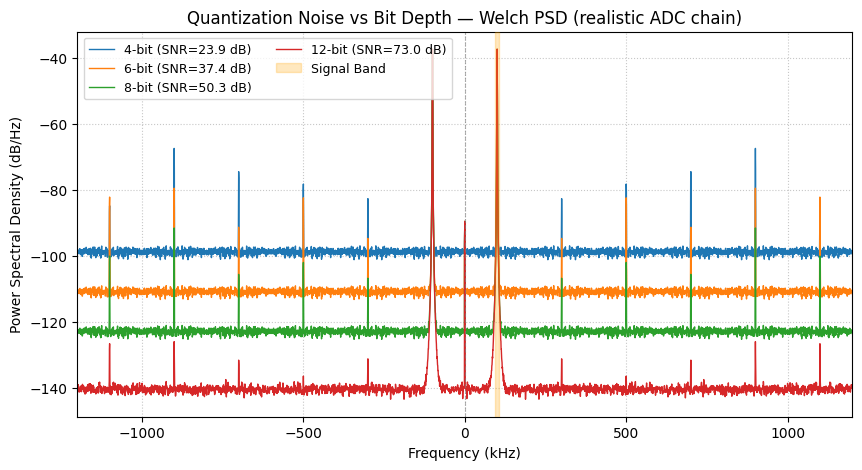

ADC Quantization: Measured vs Theoretical SNR and ENOB
(fs=2.4 MHz, tone=100 kHz, FE gain=0.95, A_in=0.90·Vref peak)
Bits  MeasSNR(dB)  IdealSNR_adj(dB)   ENOB_meas
   4        23.94             24.48          3.91
   6        37.41             36.52          6.15
   8        50.29             48.56          8.29
  12        73.03             72.64         12.07


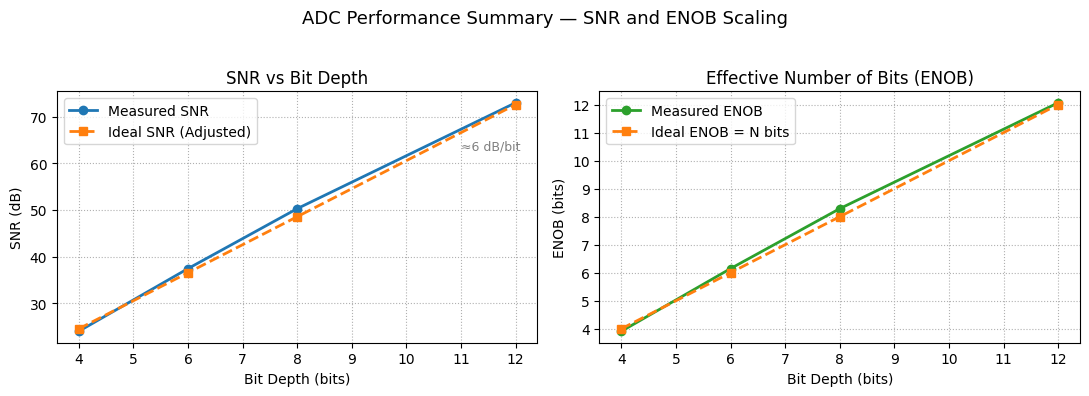

In [36]:
import numpy as np
import matplotlib.pyplot
from scipy.signal import welch

#-------------------------
#Params
#-------------------------
fs       = 2.4e6  #Sample Rate
f_tone   = 100e3  #Sample Tone
N        = 65536  #samples
Vref     = 1.0    # ADC full-scale voltage is -1 <= V <= 1
FE_gain  = 0.95   # front - end gain (AGC)
A_in     = 0.9 * Vref #Analog input before FE Gain
sigma_an = 1e-4   # analog pre-adc noise (volts rms)

t = np.arange(N)/fs
xin = A_in * np.sin(2*np.pi*f_tone*t) + np.random.default_rng(0).normal(0,sigma_an, N)
x_fe = FE_gain * xin #front end applied

#-------------------------
#Ideal mid-rise ADC quantizer
#-------------------------
def adc_quantize(x, bits, vref):
    """
    Mid-rise uniform quantizer for + / - vref input.
    returns (x_quantized_volts, integer_codes)
    """
    L = 2**bits
    delta = 2*vref / L
    #clip input to +/- vref
    x_clipped = np.clip(x,-vref,vref -1e-12) #right edge for bins
    
    #map to 0 to L-1
    codes = np.floor((x_clipped + vref)/delta).astype(int)
    #mid-rise reconstruction level (center of bins)
    xq = (codes + 0.5) * delta - vref
    return xq, codes


#fix constant enob
def total_snr(x, x_ref):
    noise = x - x_ref
    return 10*np.log10(np.mean(x_ref**2)/np.mean(noise**2))


#-------------------------
#Welch SNR Estimate
#-------------------------
def psd_snr(x, fs, f0, band_hz=10e3, nperseg=4096, noverlap=2048, search_hz=30e3):
    from scipy.signal import welch
    f, Pxx = welch(x, fs=fs, window='hann', nperseg=nperseg,
                   noverlap=noverlap, scaling='density', return_onesided=False)
    f = np.fft.fftshift(f)
    Pxx = np.fft.fftshift(Pxx)

    # --- find actual tone peak within a small search window around f0 ---
    search = (f > (f0 - search_hz)) & (f < (f0 + search_hz))
    if not np.any(search):
        # fallback: use f0 directly
        f_peak = f0
    else:
        idx_peak = np.argmax(Pxx[search])
        f_peak = f[search][idx_peak]

    # integrate ±band_hz around the detected peak
    sig_band   = (f > (f_peak - band_hz)) & (f < (f_peak + band_hz))
    noise_band = ~sig_band

    P_sig   = np.sum(Pxx[sig_band])
    P_noise = np.sum(Pxx[noise_band]) / np.sum(noise_band) * np.sum(sig_band)
    SNRdB   = 10*np.log10(P_sig/(P_noise + 1e-30))
    return SNRdB, f, Pxx, f_peak

#-------------------------
#Run for multiple bit depths
#-------------------------
bit_depts = [4, 6, 8, 12]
results = []

plt.figure(figsize=(10,5))
for i, B in enumerate(bit_depts):
    xq, _ = adc_quantize(x_fe, B, Vref)
    __, f_psd, Pxx, f_peak = psd_snr(xq, fs, f_tone)
    SNRdB = total_snr(xq, x_fe)## fix constant enob
    # Ideal quantization SNR adjusted for back-off from full-scale peak
    # Full-scale peak = Vref. Our sine peak after FE = FE_gain*A_in.
    A_peak_after = FE_gain * A_in
    backoff_dB = 20*np.log10((A_peak_after + 1e-30)/(Vref + 1e-30))  # negative for backoff
    SNR_ideal_adj = 6.02*B + 1.76 + backoff_dB

    ENOB_meas = (SNRdB - 1.76 - backoff_dB)/6.02

    results.append((B, SNRdB, SNR_ideal_adj, ENOB_meas))

    # Plot PSD (in dB/Hz)
    Pxx_db = 10*np.log10(Pxx + 1e-20)
    plt.plot(f_psd/1e3, Pxx_db, lw=1.0, label=f"{B}-bit (SNR={SNRdB:.1f} dB)")


plt.axvspan((f_tone-5e3)/1e3, (f_tone+5e3)/1e3, color='orange', alpha=0.25, zorder=3, label='Signal Band')
plt.title("Quantization Noise vs Bit Depth — Welch PSD (realistic ADC chain)")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power Spectral Density (dB/Hz)")
plt.grid(True, ls=':', alpha=0.7)
plt.xlim(-fs/(2*1e3), fs/(2*1e3))
plt.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)

plt.legend(ncol=2, fontsize=9)
plt.show()

# -----------------------------
# Print summary table
# -----------------------------
print("ADC Quantization: Measured vs Theoretical SNR and ENOB")
print(f"(fs={fs/1e6:.1f} MHz, tone={f_tone/1e3:.0f} kHz, FE gain={FE_gain:.2f}, A_in={A_in/Vref:.2f}·Vref peak)")
print("Bits  MeasSNR(dB)  IdealSNR_adj(dB)   ENOB_meas")
for B, snr_meas, snr_id, enob in results:
    print(f"{B:>4}  {snr_meas:11.2f}      {snr_id:12.2f}      {enob:8.2f}") 
    
# -----------------------------
# Visualization: SNR and ENOB vs Bit Depth
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np

# Extract data
bits = np.array([r[0] for r in results])
snr_meas = np.array([r[1] for r in results])
snr_ideal = np.array([r[2] for r in results])
enob_meas = np.array([r[3] for r in results])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# --- SNR vs Bits ---
ax1.plot(bits, snr_meas, 'o-', lw=2, label='Measured SNR')
ax1.plot(bits, snr_ideal, 's--', lw=2, label='Ideal SNR (Adjusted)')
ax1.set_xlabel("Bit Depth (bits)")
ax1.set_ylabel("SNR (dB)")
ax1.set_title("SNR vs Bit Depth")
ax1.grid(True, ls=':')
ax1.legend()
ax1.text(bits[-1]-1, snr_meas[-1]-10, "≈6 dB/bit", fontsize=9, color='gray')

# --- ENOB vs Bits ---
ax2.plot(bits, enob_meas, 'o-', lw=2, color='tab:green', label='Measured ENOB')
ax2.plot(bits, bits, 's--', lw=2, color='tab:orange', label='Ideal ENOB = N bits')
ax2.set_xlabel("Bit Depth (bits)")
ax2.set_ylabel("ENOB (bits)")
ax2.set_title("Effective Number of Bits (ENOB)")
ax2.grid(True, ls=':')
ax2.legend()

plt.suptitle("ADC Performance Summary — SNR and ENOB Scaling", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


For every bit of resolution, the noise floor decreases by 6 decible. This supports the theory. 

## Sampling & Aliasing 

### Theory
When we digitize a signal, we take **samples** at a certain rate $f_{s}$. 
If the signal contains frequency higher than half of $f_{s}$, the components **fold back** into the lower band, this is known as **aliasing**.
$$
f_{alias} = | f_{signal} -kf_{s}| \space for \space some \space integer \space k
$$
The **Nyquist Frequency** is:

$$
f_N=\frac{f_s}{2} 
$$
And the nyquist frequency is the maximum frequency that can be uniquely represented without aliasing, which means the sample frequency should be twice as much as the frequency of the actual signal:
$$
f_s \geq 2f_{max}
$$

### Code:

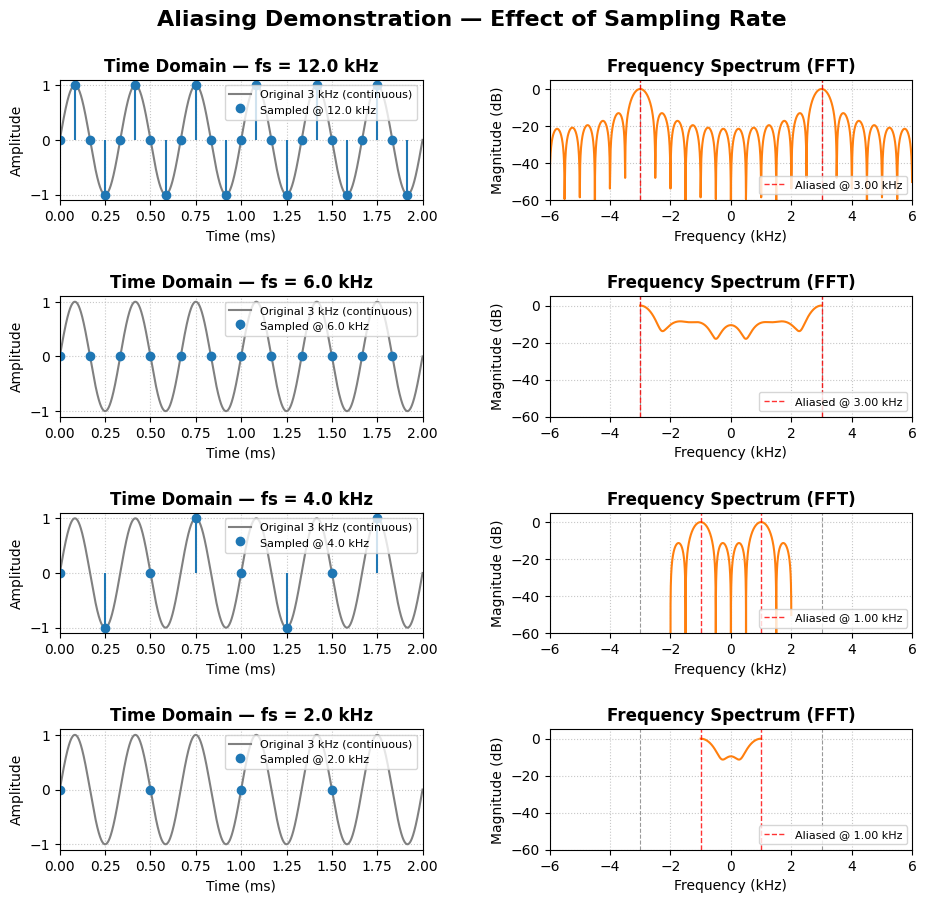

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Parameters
# -------------------------
f_signal = 3e3   # 3 kHz tone
dur = 2e-3       # 2 ms duration
fs_list = [12e3, 6e3, 4e3, 2e3]  # sample rates (above, equal, below Nyquist)

# -------------------------
# Generate continuous signal
# -------------------------
t_cont = np.linspace(0, dur, 10000)
x_cont = np.sin(2*np.pi*f_signal*t_cont)

# -------------------------
# Plot setup
# -------------------------
fig, axes = plt.subplots(len(fs_list), 2, figsize=(11, 10))  # Taller figure
plt.subplots_adjust(hspace=0.8, wspace=0.35)  # More vertical space between rows
fig.suptitle("Aliasing Demonstration — Effect of Sampling Rate", fontsize=16, weight='bold', y=0.95)

# -------------------------
# Loop through sampling rates
# -------------------------
for i, fs in enumerate(fs_list):
    # Sample signal
    t = np.arange(0, dur, 1/fs)
    x = np.sin(2*np.pi*f_signal*t)

    # Compute FFT
    N = 2048
    X = np.fft.fftshift(np.fft.fft(x, N))
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    mag_db = 20*np.log10(np.abs(X)/np.max(np.abs(X)) + 1e-12)

    # Compute alias frequency
    f_alias = abs(f_signal - round(f_signal/fs) * fs)

    # ---- Time-domain plot ----
    ax_t = axes[i, 0]
    ax_t.plot(t_cont * 1e3, x_cont, 'gray', lw=1.5, label='Original 3 kHz (continuous)')
    ax_t.stem(t * 1e3, x, linefmt='C0-', markerfmt='C0o', basefmt=" ", label=f'Sampled @ {fs/1e3:.1f} kHz')
    ax_t.set_title(f"Time Domain — fs = {fs/1e3:.1f} kHz", fontsize=12, weight='bold')
    ax_t.set_xlabel("Time (ms)")
    ax_t.set_ylabel("Amplitude")
    ax_t.set_xlim(0, dur*1e3)
    ax_t.legend(loc='upper right', fontsize=8)
    ax_t.grid(True, ls=':', alpha=0.7)

    # ---- Frequency-domain plot ----
    ax_f = axes[i, 1]
    ax_f.plot(freqs/1e3, mag_db, 'C1', lw=1.5)
    ax_f.axvline(f_signal/1e3, color='gray', ls='--', lw=0.8, alpha=0.8)
    ax_f.axvline(-f_signal/1e3, color='gray', ls='--', lw=0.8, alpha=0.8)
    ax_f.axvline(f_alias/1e3, color='r', ls='--', lw=1.0, alpha=0.8, label=f"Aliased @ {f_alias/1e3:.2f} kHz")
    ax_f.axvline(-f_alias/1e3, color='r', ls='--', lw=1.0, alpha=0.8)
    ax_f.set_xlim(-6, 6)
    ax_f.set_ylim(-60, 5)
    ax_f.set_title("Frequency Spectrum (FFT)", fontsize=12, weight='bold')
    ax_f.set_xlabel("Frequency (kHz)")
    ax_f.set_ylabel("Magnitude (dB)")
    ax_f.legend(loc='lower right', fontsize=8)
    ax_f.grid(True, ls=':', alpha=0.7)

plt.show()


## Complex Mixing (IQ), and Baseband Conversion

### Theory

When an SDR recieves a signal, the radio signal is at a very high frequency. To process it efficiently at a digital form, it must be shifted to a much lower frequency - close to **baseband** (centered at 0 Hz).
This is called **Mixing Down / Frequency Translation**.

To do so , we use a **complex explonential** (like what we've seen for fft's) as the local oscillator (LO):
$$
x_{mix}(t)=x_{RF}(t)\cdot e^{-j2\pi f_{LO} t}
$$
This process shifts the RF Frequency down, such that:
$$
f_{new}=f_{RF} - f_{LO}
$$

Choosing $f_{LO}$ to be the same as $f_{RF}$ (ie. Local oscillator = 2.4GHz, RF = 2.4GHz) the signal moves to **0 Hz** (baseband)

$$
x_{mixed}(t) = A\cdot e^{j2\pi (f_{RF}-f_{LO} t)}
$$
$$
f_{RF} =f_{LO} ,\space x_{mixed}(t) = A\cdot e^{j\cdot 0} = A \cdot 1 = A
$$

In laymans terms, we are turning our signal into an easy to measure DC**(Baseband)** Signal that can be further processed.

## Low-Pass Filtering and Decimation

### Theory
Once at baseband frequency, we only need to keep the signal around 0 Hz - the desired **bandwidth B**.
We will apply a **low-pass filter (LPF)** to remove anything outside this bandwidth.

Then, since the signal's new bandwidth will be much smaller, we can **decimate** the sample rate (reduce sample rate) by a factor of **R** -
*this can only be done after filtering, or else aliasing will occur*
$$
f_{s,new} = \frac {f_s}{R}
$$

This process is what SDR front-ends do when tunned into a station / frequency while avoiding aliasing.

### Code :

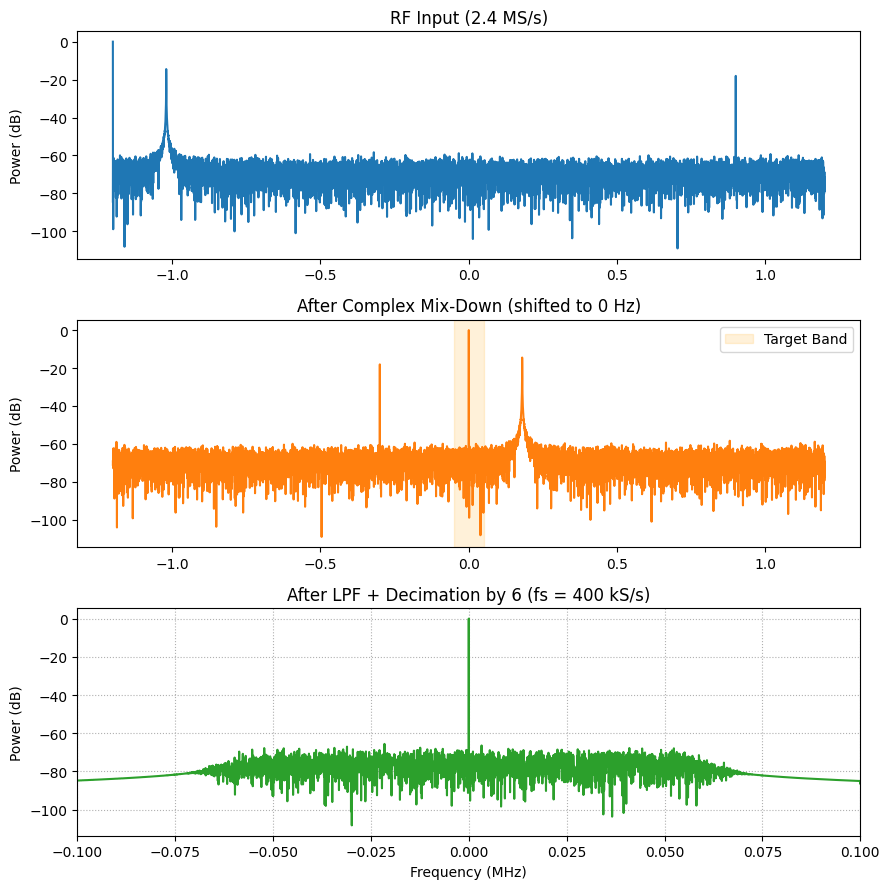

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin

# -------------------------
# Params
# -------------------------
fs  = 2.4e6  #sample rate
fRF = 1.20e6 # RF Tone
BW  = 100e3  # Desired channel bandwidth
N   = 2**18  # Samples
rng = np.random.default_rng(0) 

#Simulate input: main tone + out-of-band interference + Noise
t = np.arange(N)/fs
x = (0.8*np.exp(1j*2*np.pi*fRF*t)+  #main RF tone
     0.2*np.exp(1j*2*np.pi*(fRF+180e3)*t) + #out of band tone
     0.1 *np.exp(1j*2*np.pi*(fRF-300e3)*t))
x += (rng.normal(0, 0.02, N) + 1j*rng.normal(0, 0.02, N)) #noise + signal(RF + out of band)

# -------------------------
# Mix-Down ( freq translation)
# -------------------------

"""
You will see two signals, One that is a straight line, and one that looks like 
a proper 'oscillating signal'. 

This was confusing to me at first, but understand that we mixed our initial
signal to DC, which is why it is a straight line.

We can play with it by detuning the LO by adding / subtracting to fRF

TL;DR:

Our straight line (0Hz) is intended, the oscillating signal is out of band.



"""
fLO = fRF# sets to 0 Hz, see theory
lo = np.exp(-1j*2*np.pi*fLO*t) # local oscillator
x_mixed = x * lo # shift RF to baseband

# -------------------------
# Low pass filter
# -------------------------
cutoff = 0.6 * BW
h = firwin(321, cutoff = cutoff, fs=fs)
x_filt = np.convolve(x_mixed, h, mode='same')

# -------------------------
# Decimation
# -------------------------
R = 6 #decimation factor
fs_new = fs/R
x_dec = x_filt[::R]

# -------------------------
# Plot Frequency Spectra
# -------------------------
def psd(x, fs, nfft = 8192):
    X = np.fft.fftshift(np.fft.fft(x,nfft))
    f = np.fft.fftshift(np.fft.fftfreq(nfft, 1/fs))
    return f/1e6, 10*np.log10(np.abs(X)**2 / np.max(np.abs(X)**2))

fix, axs = plt.subplots(3, 1, figsize=(9,9))
plt.subplots_adjust(hspace=0.6)

f1, P1 = psd(x, fs)
f2, P2 = psd(x_mixed, fs)
f3, P3 = psd(x_dec, fs_new)

#input
axs[0].plot(f1, P1)
axs[0].set_title("RF Input (2.4 MS/s)") #mega-samples per sec
axs[0].set_ylabel("Power (dB)")

#input mixed
axs[1].plot(f2, P2, color='tab:orange')
axs[1].set_title("After Complex Mix-Down (shifted to 0 Hz)")
axs[1].set_ylabel("Power (dB)")
axs[1].axvspan(-BW/2/1e6, BW/2/1e6, color='orange', alpha = 0.15, label ='Target Band')
axs[1].legend()

axs[2].plot(f3, P3, color='tab:green')
axs[2].set_title(f"After LPF + Decimation by {R} (fs = {fs_new/1e3:.0f} kS/s)") #kiloSamples per second
axs[2].set_xlabel("Frequency (MHz)")
axs[2].set_ylabel("Power (dB)")
axs[2].set_xlim(-BW/1e6, BW/1e6)
axs[2].grid(True, ls=':')

plt.tight_layout()
plt.show()


## Digital Fine-Tuning and Residual LO Error Correction

### Theory

#### Error caused by mismatch

In a perfect world, aka our simulations, the **local oscillator** will mix perfectly with the RF signal so that the signal sits at DC in baseband. 
However, this is never perfect. This error shows up as a **residual frequency error**, which causes the baseband signal to **slowly rotate** in the complex(I/Q) Plane.

Lets start with the original equation:
$$
x_{mixed}(t) = A\cdot e^{j2\pi (f_{RF}-f_{LO} t)}
$$

Assuming $f_{RF} \neq f_{LO}$, we can say that $\Delta f = f_{RF} - f_{LO}$:
$$
X_{mixed}(n) = A\cdot e^{j2\pi \frac{\Delta f n}{f_s} }
$$

This means that $A\cdot e^{j2\pi \frac{\Delta f}{f_s} }$ term means the phasor will keep rotating, rather than be at 0 Hz it will be $ \pm \Delta f$. This can cause failures in decoding and demodulating certain techniques such as QPSK. 

#### Fixing it Digitally

We can fix the residual frequency using a **Numerically Controlled Oscillator (NCO)**, Which acts as a digital sine-wave generator we multiply with the signal to "derotate" it. 

But to do so, we need to estimate the offset. 
There are two simple ways:

##### a.) FFT-Peak Estimate

Take a FFT of the baseband and find where the largest magnitude peak sits. 
This will give a course estimate of $\Delta f$, which is good for small data sets or when expecting a single tone.

##### b.) Phase- Difference Estimate

A faster and cleaner trick for narrowband or high-SNR sigals:
$$
\hat \omega = \angle(mean(x[n]x^*[n-1]))
$$
$$
\hat f = \frac{\hat \omega f_s} {2 \pi}
$$

This measures the *average phase advance per sample*.
If you phase increases by 0.0157 rad per sample at 16 kHz, that's roughly a 40 Hz offset. 

Once you have $\hat f$, you can apply the correction to the original formula:
$$
X_{mixed}(n) = x[n]\cdot e^{j2\pi \frac{\hat f n}{f_s} }
$$

This will allow the tone / carrier to move back to DC. 

### code :


True Δf = 6000.0 Hz
Estimated Δf = 6016.89 Hz


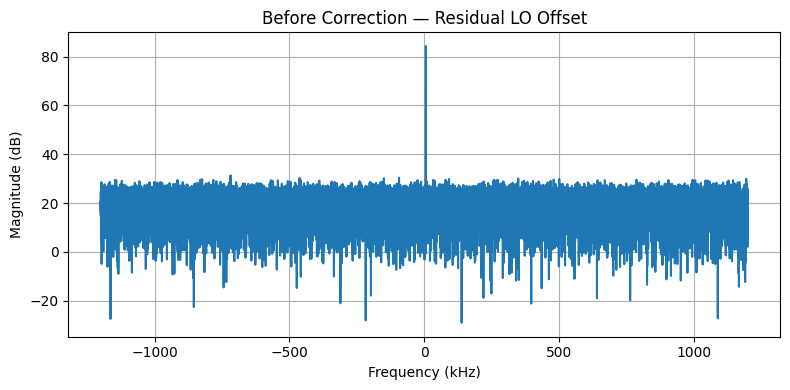

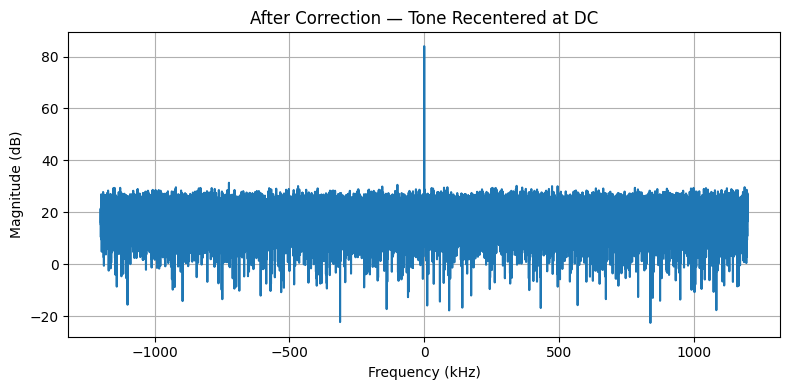

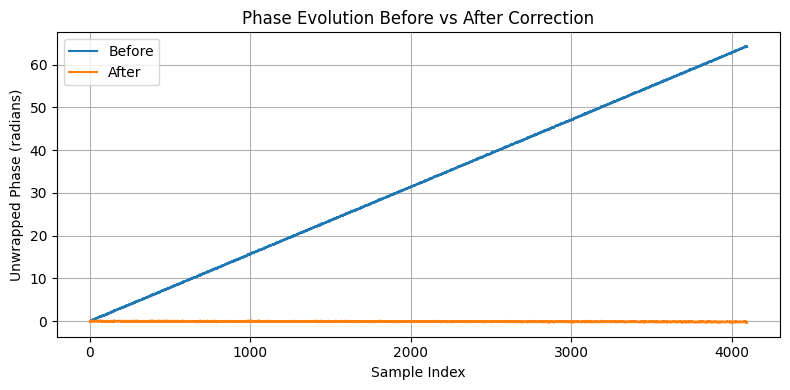

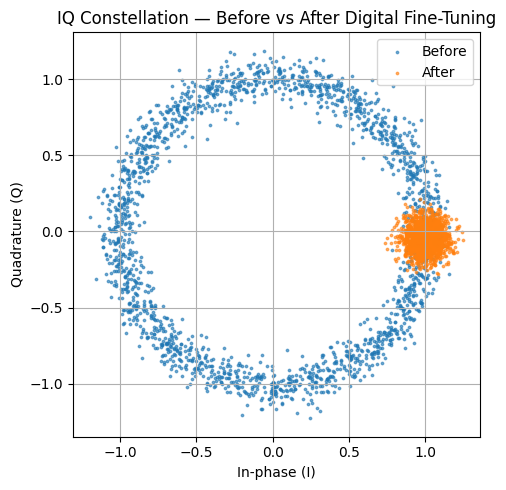

In [54]:
import numpy as np
import matplotlib.pyplot as plt

#------------------------------------
# Parameters
#------------------------------------
fs = 2.4e6        # Sample rate (Hz)
N = 2**15         # Samples
delta_f = 6e3     # Residual LO offset (Hz)
A = 1.0           # Tone amplitude
SNR_dB = 20       # Additive noise
np.random.seed(0)

#------------------------------------
# Simulated received signal
#------------------------------------
n = np.arange(N)
x_clean = A * np.exp(1j * 2*np.pi * delta_f * n / fs)
noise_power = (A**2) / (2 * 10**(SNR_dB/10))
noise = np.sqrt(noise_power) * (np.random.randn(N) + 1j*np.random.randn(N))
x = x_clean + noise

#------------------------------------
# Frequency estimation (phase difference method)
#------------------------------------
def estimate_freq(x, fs):
    x1 = x[1:]
    x0 = x[:-1]
    return np.angle(np.mean(x1 * np.conj(x0))) * fs / (2*np.pi)

f_hat = estimate_freq(x, fs)

#------------------------------------
# Apply digital correction (NCO derotation)
#------------------------------------
phi = -2*np.pi * f_hat * n / fs
y = x * np.exp(1j * phi)

#------------------------------------
# Plot: Spectrum before and after correction
#------------------------------------
def plot_fft(signal, fs, title):
    N = len(signal)
    X = np.fft.fftshift(np.fft.fft(signal * np.hanning(N)))
    f = np.fft.fftshift(np.fft.fftfreq(N, 1/fs))
    plt.figure(figsize=(8,4))
    plt.plot(f/1e3, 20*np.log10(np.abs(X)+1e-15))
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()

plot_fft(x, fs, "Before Correction — Residual LO Offset")
plot_fft(y, fs, "After Correction — Tone Recentered at DC")

#------------------------------------
# Plot: Phase vs Time (first few ms)
#------------------------------------
plt.figure(figsize=(8,4))
plt.plot(np.unwrap(np.angle(x[:4096])), label="Before")
plt.plot(np.unwrap(np.angle(y[:4096])), label="After")
plt.title("Phase Evolution Before vs After Correction")
plt.xlabel("Sample Index")
plt.ylabel("Unwrapped Phase (radians)")
plt.legend()
plt.grid(True)
plt.tight_layout()

#------------------------------------
# Plot: Constellation
#------------------------------------
plt.figure(figsize=(5,5))
plt.scatter(np.real(x[:2000]), np.imag(x[:2000]), s=3, alpha=0.6, label="Before")
plt.scatter(np.real(y[:2000]), np.imag(y[:2000]), s=3, alpha=0.6, label="After")
plt.title("IQ Constellation — Before vs After Digital Fine-Tuning")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.tight_layout()

print(f"True Δf = {delta_f:.1f} Hz")
print(f"Estimated Δf = {f_hat:.2f} Hz")
